In [2]:
##Import Libraries and  Load data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/DataSet/Walmart_Store_sales.csv")

df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


In [3]:
## Data Cleaning
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Week"] = df["Date"].dt.isocalendar().week
df["Day"] = df["Date"].dt.day

df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Week,Day
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2,5,5
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2010,2,6,12
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2010,2,7,19
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2010,2,8,26
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3,9,5


In [4]:
df.isnull().sum()

,0
Store,0
Date,0
Weekly_Sales,0
Holiday_Flag,0
Temperature,0
Fuel_Price,0
CPI,0
Unemployment,0
Year,0
Month,0


In [5]:
### Basic Statistics Task
##Task-1 Which store has maximum sale?
store_sales = df.groupby("Store")["Weekly_Sales"].sum()

store_sales.idxmax()
store_sales.max()

301397792.46

In [6]:
## Task 2 Store With highest standard deviation
std_sales = df.groupby("Store")["Weekly_Sales"].std()

std_sales.idxmax()

np.int64(14)

In [11]:
##CV = std / mean

In [7]:
mean_sales = df.groupby("Store")["Weekly_Sales"].mean()

cv = std_sales / mean_sales

cv.sort_values(ascending=False)

# Insight:

# High CV = unstable store

# Low CV = stable store

,Weekly_Sales
Store,
35,0.229681
7,0.197305
15,0.193384
29,0.183742
23,0.179721
21,0.170292
45,0.165613
16,0.165181
18,0.162845


In [8]:
##Task 3 — Quarterly growth Q3 2012
##Q3 = July Aug Sept
df_2012 = df[df["Year"] == 2012]

q2 = df_2012[df_2012["Month"].isin([4,5,6])]
q3 = df_2012[df_2012["Month"].isin([7,8,9])]

q2_sales = q2.groupby("Store")["Weekly_Sales"].sum()
q3_sales = q3.groupby("Store")["Weekly_Sales"].sum()

growth = (q3_sales - q2_sales) / q2_sales

growth.sort_values(ascending=False)


,Weekly_Sales
Store,
7,0.133308
16,0.084884
35,0.044666
26,0.039555
39,0.024784
41,0.024570
44,0.024346
24,0.016521
40,0.011428


In [9]:
## Task 4 — Holiday impact
holiday = df[df["Holiday_Flag"] == 1]
non_holiday = df[df["Holiday_Flag"] == 0]

holiday_mean = holiday["Weekly_Sales"].mean()
non_holiday_mean = non_holiday["Weekly_Sales"].mean()

holiday_mean, non_holiday_mean

(np.float64(1122887.8923555557), np.float64(1041256.3802088555))

In [10]:
##Insight:Holiday effect positive / negative

df.groupby("Holiday_Flag")["Weekly_Sales"].mean()

,Weekly_Sales
Holiday_Flag,
0,1.041256e+06
1,1.122888e+06


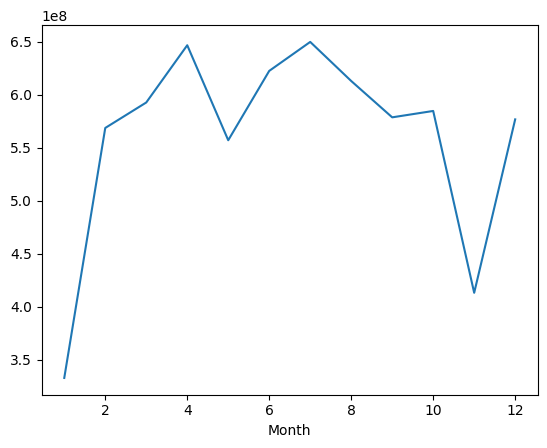

In [11]:
##Task 5 — Monthly & Semester View
monthly = df.groupby("Month")["Weekly_Sales"].sum()

monthly.plot()
plt.show()

In [12]:
df["Semester"] = df["Month"].apply(lambda x: 1 if x<=6 else 2)

semester = df.groupby("Semester")["Weekly_Sales"].sum()

semester

##Insights:

# Peak months

# Low months

# Seasonality

,Weekly_Sales
Semester,
1,3.320727e+09
2,3.416492e+09


In [25]:
## Model Bulding

In [14]:
store1 = df[df["Store"] == 1].copy()

In [15]:
### Feature Engineering
## Convert date in to Day
##Earliest date = 2010-02-05

In [16]:
store1 = store1.sort_values("Date")

store1["Days"] = (store1["Date"] - store1["Date"].min()).dt.days

In [ ]:
## features
# Days
# CPI
# Fuel_Price
# Unemployment
# Temperature
# Holiday_Flag
##Target
#Weekly_Sales

In [17]:
## Split Data in Train and Test
from sklearn.model_selection import train_test_split

X = store1[["Days","CPI","Fuel_Price","Unemployment","Temperature","Holiday_Flag"]]

y = store1["Weekly_Sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [18]:
## Linear Regression Model we Apply
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train,y_train)

pred = model.predict(X_test)

In [20]:
## error
from sklearn.metrics import r2_score, mean_absolute_error

r2_score(y_test,pred)

mean_absolute_error(y_test,pred)

117227.98636774629

In [21]:
## Check Coefficient
pd.DataFrame({
    "Feature":X.columns,
    "Coef":model.coef_
})

,Feature,Coef
0,Days,117.179934
1,CPI,6851.977060
2,Fuel_Price,-44322.344170
3,Unemployment,45707.758776
4,Temperature,-2687.084048
5,Holiday_Flag,58390.942202


In [ ]:
## Try to figure out best fit model and accuracy
# RandomForest
# XGBoost
# DecisionTree

In [22]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()

rf.fit(X_train,y_train)

pred2 = rf.predict(X_test)

r2_score(y_test,pred2)

0.24457506529705297

In [23]:
## Compare All Model
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import pandas as pd
import numpy as np

In [24]:
## Train Model
models = {

    "LinearRegression": LinearRegression(),

    "DecisionTree": DecisionTreeRegressor(random_state=42),

    "RandomForest": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ),

    "GradientBoosting": GradientBoostingRegressor(
        random_state=42
    )

}

In [25]:
## Model Comparision
results = []

for name, model in models.items():

    # train
    model.fit(X_train, y_train)

    # predict
    pred = model.predict(X_test)

    # metrics
    r2 = r2_score(y_test, pred)

    mae = mean_absolute_error(y_test, pred)

    rmse = np.sqrt(mean_squared_error(y_test, pred))

    results.append([name, r2, mae, rmse])

results_df = pd.DataFrame(
    results,
    columns=["Model", "R2", "MAE", "RMSE"]
)

results_df.sort_values(by="R2", ascending=False)
## Best model = Highest R2 + Lowest RMSE

,Model,R2,MAE,RMSE
2,RandomForest,0.167884,107742.741903,141868.095041
3,GradientBoosting,0.034733,115058.211655,152797.593459
0,LinearRegression,0.020636,117227.986368,153909.316531
1,DecisionTree,-1.048216,155794.517241,222577.175295


In [26]:
### Model Accuracy Improvement
## Feature Engineneering
df = pd.read_csv("/content/DataSet/Walmart_Store_sales.csv")

df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Week"] = df["Date"].dt.isocalendar().week.astype(int)
df["Day"] = df["Date"].dt.day
df["Quarter"] = df["Date"].dt.quarter

In [27]:
## Add LAG feature
df = df.sort_values(["Store", "Date"])

df["Lag1"] = df.groupby("Store")["Weekly_Sales"].shift(1)

df["Lag2"] = df.groupby("Store")["Weekly_Sales"].shift(2)

df["Lag3"] = df.groupby("Store")["Weekly_Sales"].shift(3)

In [28]:
### Add Rolling Mean
df["Rolling_Mean"] = (
    df.groupby("Store")["Weekly_Sales"]
    .rolling(4)
    .mean()
    .reset_index(0, drop=True)
)


In [29]:
## Drop NA after LAG
df = df.dropna()

In [30]:
## Use all stores insted only store 1
X = df[
    [
        "Store",
        "Holiday_Flag",
        "Temperature",
        "Fuel_Price",
        "CPI",
        "Unemployment",
        "Year",
        "Month",
        "Week",
        "Quarter",
        "Lag1",
        "Lag2",
        "Lag3",
        "Rolling_Mean"
    ]
]

y = df["Weekly_Sales"]

In [31]:
## Train Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [32]:
## Tuning Random Forest
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

pred = rf.predict(X_test)

In [33]:
## Lets Check Accuaracy

from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

r2 = r2_score(y_test, pred)

rmse = np.sqrt(mean_squared_error(y_test, pred))

r2, rmse

(0.9878911124535691, np.float64(60679.02161927469))

In [34]:
### Lets Split By Date
df = df.sort_values("Date")

train = df[df["Date"] < "2012-01-01"]

test = df[df["Date"] >= "2012-01-01"]

In [35]:
# Features
features = [
    "Store",
    "Holiday_Flag",
    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment",
    "Year",
    "Month",
    "Week",
    "Quarter",
    "Lag1",
    "Lag2",
    "Lag3",
    "Rolling_Mean"
]

X_train = train[features]
y_train = train["Weekly_Sales"]

X_test = test[features]
y_test = test["Weekly_Sales"]

In [36]:
## Again Train model
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

pred = rf.predict(X_test)

In [37]:
## Evaluate
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

r2 = r2_score(y_test, pred)

rmse = np.sqrt(mean_squared_error(y_test, pred))

r2, rmse

(0.9896743489991563, np.float64(54518.06105193581))

In [38]:
## Retrain
df = df.sort_values(["Store", "Date"])

train = df[df["Date"] < "2012-01-01"].copy()
test = df[df["Date"] >= "2012-01-01"].copy()

In [39]:
train["Lag1"] = train.groupby("Store")["Weekly_Sales"].shift(1)
train["Lag2"] = train.groupby("Store")["Weekly_Sales"].shift(2)
train["Lag3"] = train.groupby("Store")["Weekly_Sales"].shift(3)

train["Rolling_Mean"] = (
    train.groupby("Store")["Weekly_Sales"]
    .rolling(4)
    .mean()
    .reset_index(0, drop=True)
)

In [40]:
test["Lag1"] = test.groupby("Store")["Weekly_Sales"].shift(1)
test["Lag2"] = test.groupby("Store")["Weekly_Sales"].shift(2)
test["Lag3"] = test.groupby("Store")["Weekly_Sales"].shift(3)

test["Rolling_Mean"] = (
    test.groupby("Store")["Weekly_Sales"]
    .rolling(4)
    .mean()
    .reset_index(0, drop=True)
)

In [41]:
train = train.dropna()
test = test.dropna()

In [42]:
features = [
    "Store",
    "Holiday_Flag",
    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment",
    "Year",
    "Month",
    "Week",
    "Quarter",
    "Lag1",
    "Lag2",
    "Lag3",
    "Rolling_Mean"
]

X_train = train[features]
y_train = train["Weekly_Sales"]

X_test = test[features]
y_test = test["Weekly_Sales"]

In [43]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

pred = rf.predict(X_test)

In [44]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

r2 = r2_score(y_test, pred)

rmse = np.sqrt(mean_squared_error(y_test, pred))

r2, rmse

(0.9900713193787797, np.float64(53778.10530584732))

In [45]:
### Correct Final Model  --> TimeSeriesSplit (Industry Standard)

##Prepare feature
features = [
    "Store",
    "Holiday_Flag",
    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment",
    "Year",
    "Month",
    "Week",
    "Quarter",
    "Lag1",
    "Lag2",
    "Lag3",
    "Rolling_Mean"
]

X = df[features]
y = df["Weekly_Sales"]

In [46]:
## Use Time Series
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

In [47]:
##Train with CV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
import numpy as np

scores = []

for train_index, test_index in tscv.split(X):

    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model = RandomForestRegressor(
        n_estimators=200,
        max_depth=12,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    r2 = r2_score(y_test, pred)

    scores.append(r2)

print("Scores:", scores)
print("Mean R2:", np.mean(scores))

Scores: [0.9588199632212162, 0.9605595780754385, 0.968737363530126, 0.9842249182379622, 0.9859717488028916]
Mean R2: 0.971662714373527


In [49]:
results = []

for name, model in models.items():

    # train
    model.fit(X_train, y_train)

    # predict
    pred = model.predict(X_test)

    # metrics
    r2 = r2_score(y_test, pred)

    mae = mean_absolute_error(y_test, pred)

    rmse = np.sqrt(mean_squared_error(y_test, pred))

    results.append([name, r2, mae, rmse])

results_df = pd.DataFrame(
    results,
    columns=["Model", "R2", "MAE", "RMSE"]
)

results_df.sort_values(by="R2", ascending=False)

,Model,R2,MAE,RMSE
0,LinearRegression,1.000000,5.691046e-10,7.802432e-10
2,RandomForest,0.987321,2.946633e+04,4.504715e+04
3,GradientBoosting,0.983684,3.551331e+04,5.110106e+04
1,DecisionTree,0.972876,4.366950e+04,6.588749e+04


In [51]:
best_model_name = results_df.sort_values(
    by="R2", ascending=False
).iloc[0]["Model"]

best_model_name

'LinearRegression'

In [53]:
import pickle

best_model = models[best_model_name]

pickle.dump(
    best_model,
    open("walmart_best_model.pkl", "wb")
)

In [54]:
### Download Pickel File
from google.colab import files

files.download("walmart_best_model.pkl")



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [38]:
## Best Model
best_model_name = results_df.sort_values(
    by="R2", ascending=False
).iloc[0]["Model"]

best_model_name

'RandomForest'